# 09 — Automatic FESR pipeline: acetone [ppb]

The number and boundaries of signal segments are learned rather than predefined.
`AutomaticSegments.fit` repeatedly divides the median training cycle while the improvement in
linear reconstruction exceeds a BIC-like complexity penalty. The eight-sample minimum is a
resolution limit, not a segment count. This greedy procedure has an automatic stopping rule but
does not guarantee globally optimal segmentation. Learned boundaries remain fixed in `transform`.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p/'Networks'/'TCOCNNv3.py').exists())
for folder in ['Networks','Evaluation Seminar/Day_02','Evaluation Seminar/Day_03','Evaluation Seminar/Day_04']:
    sys.path.insert(0,str(ROOT/folder))
import numpy as np
import matplotlib.pyplot as plt
from day3_utils import plot_comparison, regression_metrics, show_results

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GridSearchCV, GroupKFold
from dataset_pipeline import prepare_splits
from automatic_fesr import AutomaticSegments, FractionSelector
splits=prepare_splits('stored'); GAS='acetone'
X=splits['train']['X']; y=splits['train']['targets'][GAS]; groups=splits['train']['targets']['range']
extractor=AutomaticSegments().fit(X)
features=extractor.transform(X)
print('Automatically learned segments:',extractor.n_segments_,'; Features:',features.shape[1])
print('Train:',len(np.unique(groups)),'UGMs /',len(y),'Zyklen')

Automatically learned segments: 28 ; Features: 56
Train: 318 UGMs / 1090 Zyklen


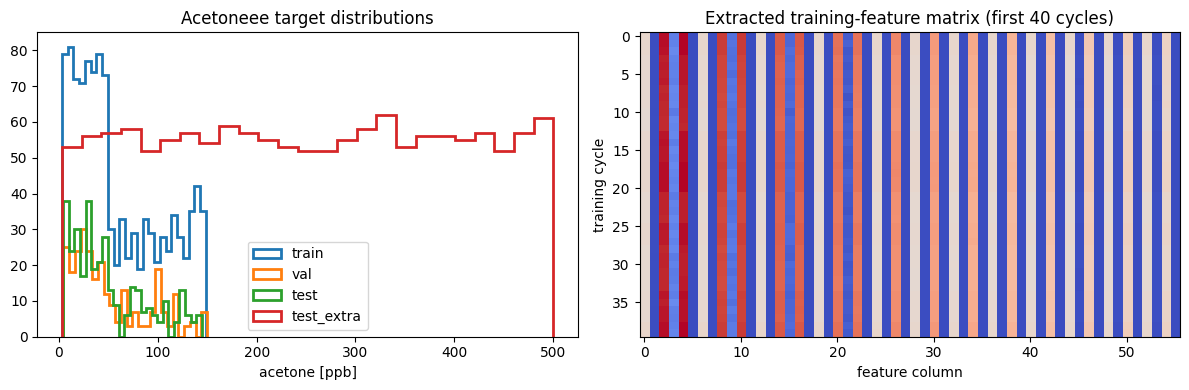

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {
    "train": "tab:blue",
    "val": "tab:orange",
    "test": "tab:green",
    "test_extra": "tab:red",
}
for split_name in ("train", "val", "test", "test_extra"):
    targets = splits[split_name]["targets"][GAS]
    axes[0].hist(
        targets,
        bins=25,
        histtype="step",
        linewidth=2,
        color=colors[split_name],
        label=split_name,
    )
axes[0].set(title="Acetoneee target distributions", xlabel="acetone [ppb]")
axes[0].legend()
axes[1].imshow(features[:40], aspect="auto", cmap="coolwarm")
axes[1].set(
    title="Extracted training-feature matrix (first 40 cycles)",
    xlabel="feature column",
    ylabel="training cycle",
)
fig.tight_layout()

## Automatic segmentation and stopping

Orange lines show the linear reconstruction within learned segments. The right panel shows the
complexity score along the accepted search path. Segment boundaries are relearned inside every
cross-validation training fold; validation and test cycles never determine them.

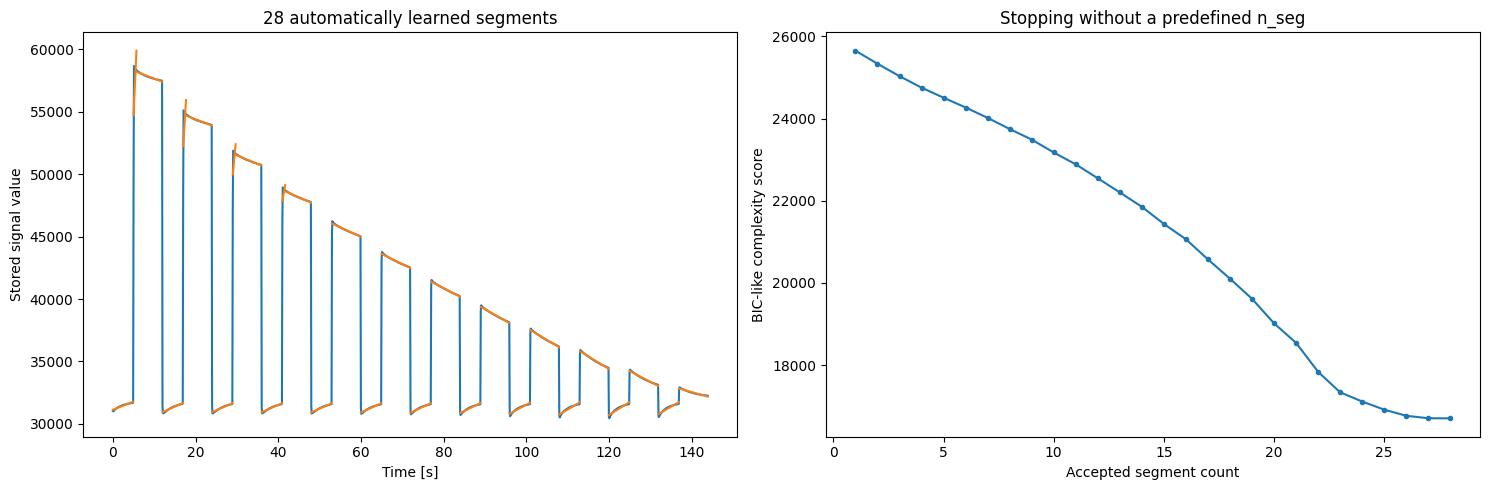

In [3]:
fig,axes=plt.subplots(1,2,figsize=(15,5)); time=np.arange(X.shape[-1])/10
axes[0].plot(time,extractor.reference_,label='Training median')
for i,(a,b) in enumerate(zip(extractor.boundaries_[:-1],extractor.boundaries_[1:])):
    t=time[a:b]; centered=t-t.mean(); values=extractor.reference_[a:b]
    fitted=values.mean()+centered*(values@centered)/(centered@centered)
    axes[0].plot(t,fitted,color='tab:orange')
axes[0].set(title=f'{extractor.n_segments_} automatically learned segments',xlabel='Time [s]',ylabel='Stored signal value')
path=np.asarray(extractor.path_); axes[1].plot(path[:,0],path[:,1],marker='.')
axes[1].set(xlabel='Accepted segment count',ylabel='BIC-like complexity score',title='Stopping without a predefined n_seg')
plt.tight_layout(); plt.show()

## scikit-learn pipeline: learn every step inside the training fold

The pipeline is `AutomaticSegments → StandardScaler → FractionSelector → PLSRegression`.
Because feature count varies by fold, selection uses a fraction rather than a fixed count.
Pearson and RFE/Ridge are compared with grouped cross-validation; separate validation chooses the
final variant. Every acetone metric is reported in ppb.

pearson {'regression__n_components': 2, 'select__fraction': 0.5, 'select__method': 'pearson'}
rfe {'regression__n_components': 2, 'select__fraction': 1.0, 'select__method': 'rfe'}


Method,CV_RMSE_ppb,Segments,RMSE_ppb,MAE_ppb,R2,bias_ppb
pearson,31.464,28,29.486,22.325,0.424,0.609
rfe,33.541,28,29.035,21.544,0.441,2.561


Fold,Training UGMs,Segments
1,212,28
2,212,28
3,212,28


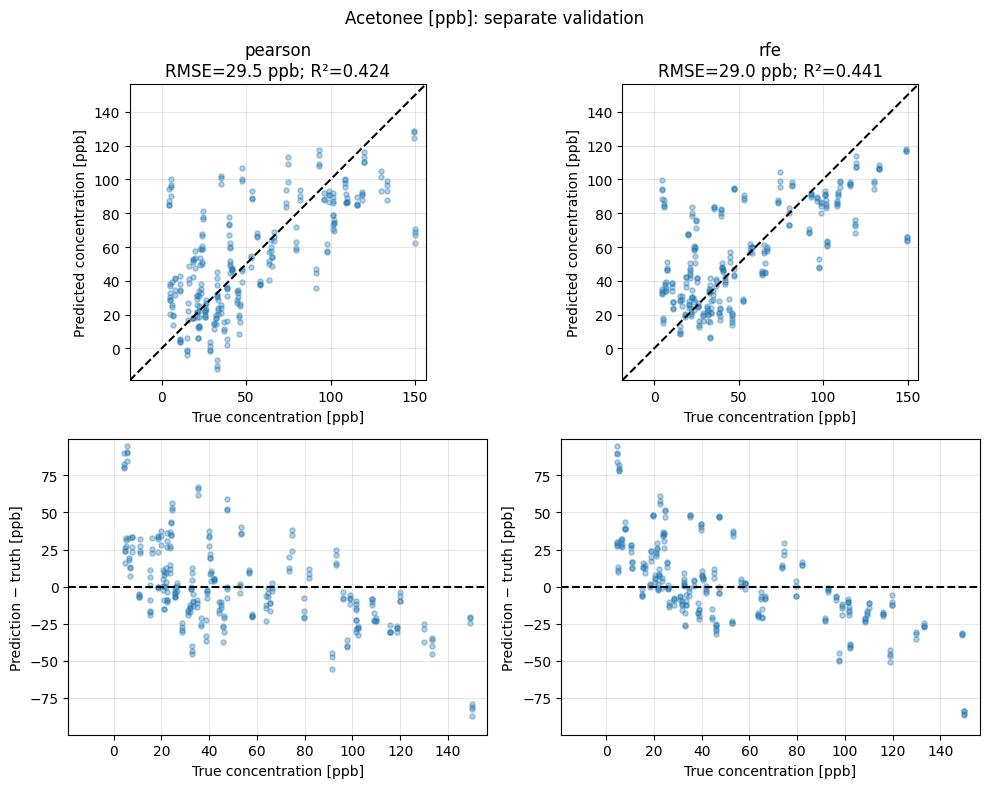

In [4]:
pipeline=Pipeline([('features',AutomaticSegments()),('scale',StandardScaler()),
                   ('select',FractionSelector()),('regression',PLSRegression(scale=False))])
searches={}; predictions={}; rows=[]
for method in ['pearson','rfe']:
    grid={'select__method':[method],'select__fraction':[.25,.5,1.], 'regression__n_components':[1,2]}
    search=GridSearchCV(pipeline,grid,cv=GroupKFold(3),scoring='neg_root_mean_squared_error',n_jobs=1,error_score='raise')
    search.fit(X,y,groups=groups); searches[method]=search
    predictions[method]=search.predict(splits['val']['X']).ravel()
    rows.append({'Method':method,'CV_RMSE_ppb':-search.best_score_,
                 'Segments':search.best_estimator_.named_steps['features'].n_segments_,
                 **regression_metrics(splits['val']['targets'][GAS],predictions[method])})
    print(method,search.best_params_)
show_results(rows)
fold_rows=[]
for fold,(train_idx,_) in enumerate(GroupKFold(3).split(X,y,groups),1):
    learned=AutomaticSegments().fit(X[train_idx])
    fold_rows.append({'Fold':fold,'Training UGMs':len(np.unique(groups[train_idx])),'Segments':learned.n_segments_})
show_results(fold_rows)
plot_comparison(splits['val']['targets'][GAS],predictions,'Acetonee [ppb]: separate validation')

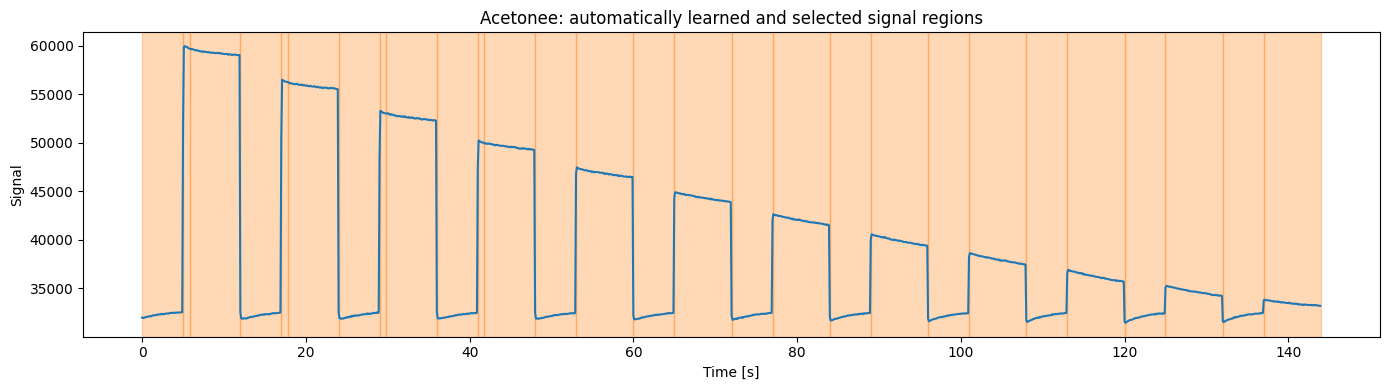

Selected features: ['segment000_0000-0049_mean', 'segment000_0000-0049_slope_per_s', 'segment001_0050-0057_mean', 'segment001_0050-0057_slope_per_s', 'segment002_0058-0119_mean', 'segment002_0058-0119_slope_per_s', 'segment003_0120-0169_mean', 'segment003_0120-0169_slope_per_s', 'segment004_0170-0177_mean', 'segment004_0170-0177_slope_per_s', 'segment005_0178-0239_mean', 'segment005_0178-0239_slope_per_s', 'segment006_0240-0289_mean', 'segment006_0240-0289_slope_per_s', 'segment007_0290-0297_mean', 'segment007_0290-0297_slope_per_s', 'segment008_0298-0359_mean', 'segment008_0298-0359_slope_per_s', 'segment009_0360-0409_mean', 'segment009_0360-0409_slope_per_s', 'segment010_0410-0417_mean', 'segment010_0410-0417_slope_per_s', 'segment011_0418-0479_mean', 'segment011_0418-0479_slope_per_s', 'segment012_0480-0529_mean', 'segment012_0480-0529_slope_per_s', 'segment013_0530-0599_mean', 'segment013_0530-0599_slope_per_s', 'segment014_0600-0649_mean', 'segment014_0600-0649_slope_per_s', 'segm

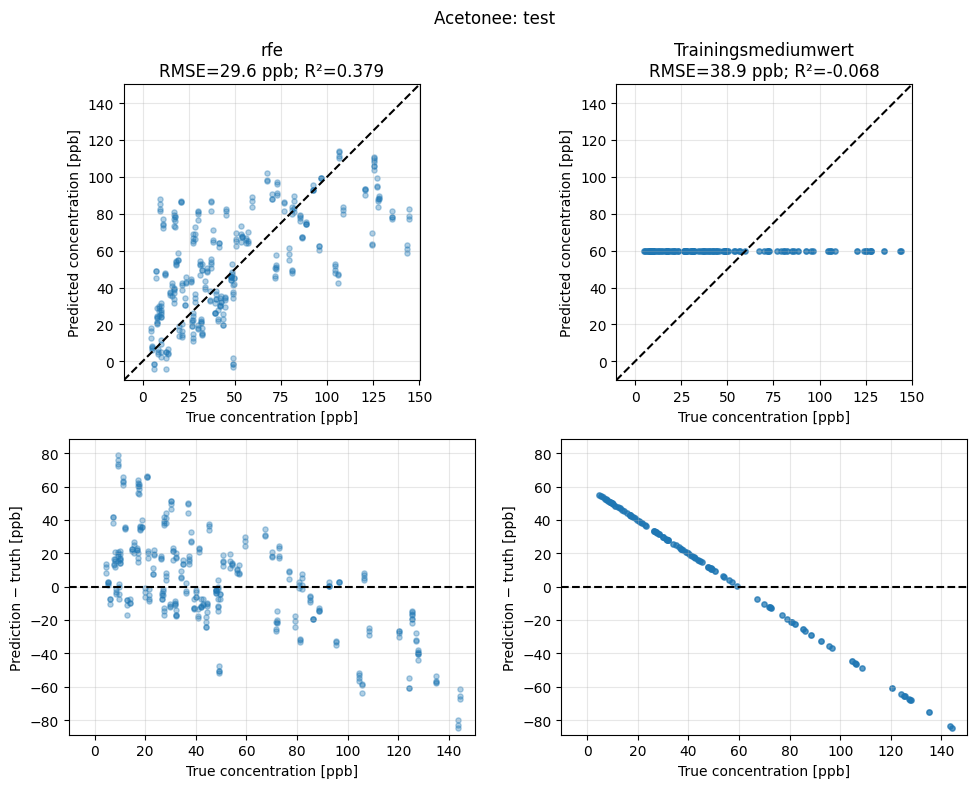

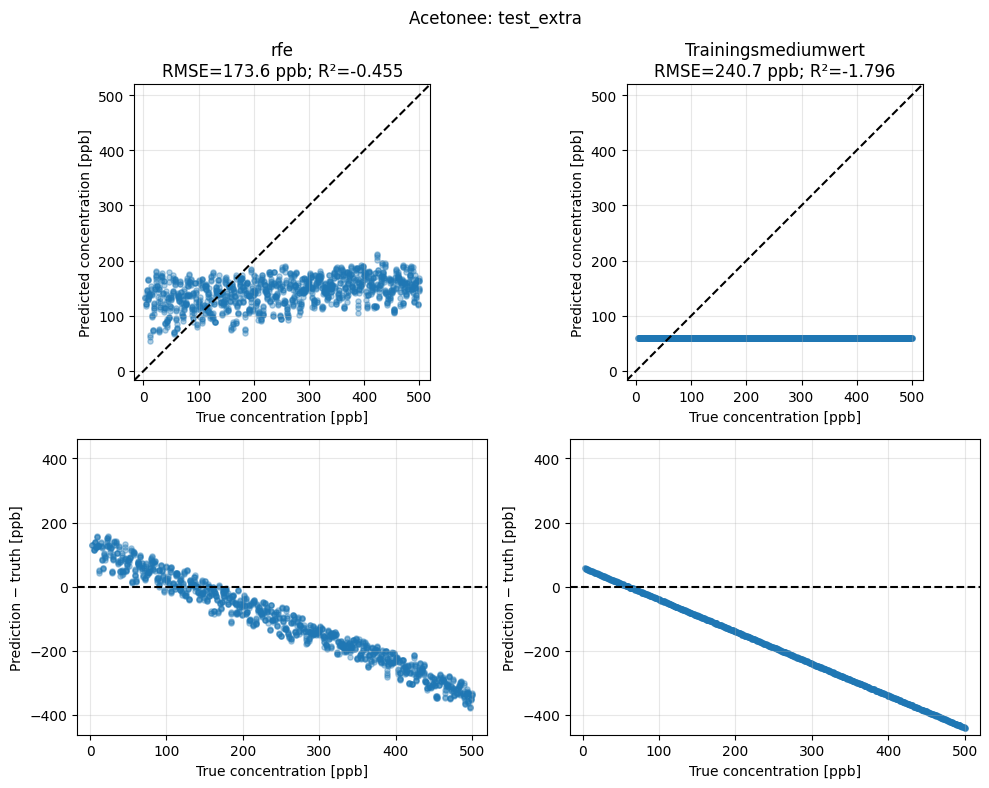

Split,RMSE_ppb,MAE_ppb,R2,bias_ppb
test,29.636,22.779,0.379,2.553
test_extra,173.616,141.967,-0.455,-108.957


In [5]:
winner=min(rows,key=lambda row:row['RMSE_ppb'])['Method']; fitted=searches[winner].best_estimator_
fe=fitted.named_steps['features']; selected=fitted.named_steps['select'].indices_
plt.figure(figsize=(14,4)); plt.plot(time,X[0,0])
for segment in np.unique(selected//2):
    a,b=fe.boundaries_[segment:segment+2]; plt.axvspan(a/10,b/10,color='tab:orange',alpha=.3)
plt.title('Acetonee: automatically learned and selected signal regions'); plt.xlabel('Time [s]'); plt.ylabel('Signal')
plt.tight_layout(); plt.show()
print('Selected features:',fe.get_feature_names_out()[selected].tolist())
final=[]
for name in ['test','test_extra']:
    truth=splits[name]['targets'][GAS]; pred=fitted.predict(splits[name]['X']).ravel()
    plot_comparison(truth,{winner:pred,'Trainingsmediumwert':np.full(len(truth),y.mean())},'Acetonee: '+name)
    final.append({'Split':name,**regression_metrics(truth,pred)})
show_results(final)